In [2]:
library(tidyverse)
library(lubridate)
library(scales)
# Install writexl if not already installed
if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl")
}
library(writexl)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
datos <- read_csv("ventas.csv")


Rows: 500 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): fecha_venta, id_producto, producto, categoria, region, vendedor, pr...
dbl (3): id_venta, cantidad, descuento_pct

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
glimpse(datos)
summary(datos)

Rows: 500
Columns: 11
$ id_venta        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ fecha_venta     <chr> "01/08/2024", "10/11/2024", "2024-04-22", "30/01/2024"…
$ id_producto     <chr> "P027", "P008", "P012", "P012", "P012", "P015", "P009"…
$ producto        <chr> "Televisor", "SILLA", "Cereal", "Televisor", "Playera"…
$ categoria       <chr> "Hogar", NA, NA, "Hogar", "Alimento", NA, "Ropa", "Ali…
$ region          <chr> "Sur", "Sur", "Norte", "Oriente", "Centro", "Sur", "Or…
$ vendedor        <chr> "Carlos Ruiz", "ANA LOPEZ", "Ana López", "ana lopez", …
$ cantidad        <dbl> 46, 29, 25, 14, 13, 1, 11, 35, 14, 24, 42, 43, 26, 37,…
$ precio_unitario <chr> "250", "8000", NA, "8000", "$250", NA, "1200", "1200",…
$ descuento_pct   <dbl> 25, 5, 30, NA, NA, 5, 20, 0, 5, 15, 10, NA, NA, 25, NA…
$ canal_venta     <chr> "Distribuidor", "Distribuidor", "Distribuidor", "Tiend…


    id_venta        fecha_venta     id_producto       producto  
 Min.   :  1.0   Length   :500   Length   :500   Length   :500  
 1st Qu.:125.8   N.unique :291   N.unique : 30   N.unique : 11  
 Median :250.5   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Mean   :250.5   Min.nchar: 10   Min.nchar:  4   Min.nchar:  5  
 3rd Qu.:375.2   Max.nchar: 10   Max.nchar:  4   Max.nchar:  9  
 Max.   :500.0   NAs      :  1                                  
                                                                
     categoria         region         vendedor      cantidad     
 Length   :500   Length   :500   Length   :500   Min.   :-10.00  
 N.unique :  4   N.unique :  5   N.unique :  7   1st Qu.: 12.00  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   Median : 25.00  
 Min.nchar:  4   Min.nchar:  3   Min.nchar:  9   Mean   : 24.42  
 Max.nchar: 11   Max.nchar:  9   Max.nchar: 12   3rd Qu.: 37.25  
 NAs      : 50                                   Max.   : 50.00  
                  

In [6]:
faltantes <- datos |>
  summarise(across(everything(), ~sum(is.na(.)))) |>
  pivot_longer(cols = everything(),
               names_to = "columna",
               values_to = "valores_faltantes")

print(faltantes)

# A tibble: 11 × 2
   columna         valores_faltantes
   <chr>                       <int>
 1 id_venta                        0
 2 fecha_venta                     1
 3 id_producto                     0
 4 producto                        0
 5 categoria                      50
 6 region                          0
 7 vendedor                        0
 8 cantidad                        0
 9 precio_unitario                54
10 descuento_pct                  67
11 canal_venta                   120


In [7]:
datos_limpios <- datos |>
  mutate(
    # La fecha viene en dos formatos: "dd/mm/aaaa" y "aaaa-mm-dd"
    fecha_venta = parse_date_time(fecha_venta, orders = c("dmy", "ymd")),

    # Estandarizar textos para evitar duplicados por mayusculas/minusculas
    producto = str_to_title(str_squish(producto)),
    categoria = replace_na(categoria, "Sin Categoria"),
    categoria = str_to_title(str_squish(categoria)),
    region = str_to_title(str_squish(region)),

    # Quitar acentos para que "Ana Lopez" y "Ana López" no salgan separados
    vendedor = iconv(vendedor, from = "", to = "ASCII//TRANSLIT"),
    vendedor = str_to_title(str_squish(vendedor)),

    canal_venta = replace_na(canal_venta, "No Especificado"),
    canal_venta = str_to_title(str_squish(canal_venta)),

    # El precio viene como texto y algunos valores tienen "$"
    precio_unitario = parse_number(as.character(precio_unitario)),

    # Si el descuento esta vacio, se toma como 0%
    descuento_pct = replace_na(descuento_pct, 0),

    # Crear variables para el analisis
    total_bruto = cantidad * precio_unitario,
    monto_descuento = total_bruto * (descuento_pct / 100),
    total_neto = total_bruto - monto_descuento,

    # Variables de tiempo
    anio = year(fecha_venta),
    mes_num = month(fecha_venta),
    mes = month(fecha_venta, label = TRUE, abbr = FALSE),
    trimestre = quarter(fecha_venta)
  ) |>
  # Para calcular ventas reales, se quitan registros sin fecha o sin precio
  drop_na(fecha_venta, precio_unitario)


In [8]:
glimpse(datos_limpios)
summary(datos_limpios)

Rows: 445
Columns: 18
$ id_venta        <dbl> 1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 1…
$ fecha_venta     <dttm> 2024-08-01, 2024-11-10, 2024-01-30, 2024-07-05, 2024-…
$ id_producto     <chr> "P027", "P008", "P012", "P012", "P009", "P024", "P003"…
$ producto        <chr> "Televisor", "Silla", "Televisor", "Playera", "Playera…
$ categoria       <chr> "Hogar", "Sin Categoria", "Hogar", "Alimento", "Ropa",…
$ region          <chr> "Sur", "Sur", "Oriente", "Centro", "Oriente", "Sur", "…
$ vendedor        <chr> "Carlos Ruiz", "Ana Lopez", "Ana Lopez", "Carlos Ruiz"…
$ cantidad        <dbl> 46, 29, 14, 13, 11, 35, 14, 24, 42, 43, 26, -10, 29, 2…
$ precio_unitario <dbl> 250, 8000, 8000, 250, 1200, 1200, 3500, 250, 500, 1200…
$ descuento_pct   <dbl> 25, 5, 0, 0, 20, 0, 5, 15, 10, 0, 0, 0, 30, 0, 30, 20,…
$ canal_venta     <chr> "Distribuidor", "Distribuidor", "Tienda", "Online", "N…
$ total_bruto     <dbl> 11500, 232000, 112000, 3250, 13200, 42000, 49000, 6000…
$ monto_descuento 

    id_venta      fecha_venta                     id_producto       producto  
 Min.   :  1.0   Min.   :2024-01-01 00:00:00   Length   :445   Length   :445  
 1st Qu.:125.0   1st Qu.:2024-04-12 00:00:00   N.unique : 30   N.unique :  5  
 Median :245.0   Median :2024-07-02 00:00:00   N.blank  :  0   N.blank  :  0  
 Mean   :248.7   Mean   :2024-07-03 23:53:31   Min.nchar:  4   Min.nchar:  5  
 3rd Qu.:370.0   3rd Qu.:2024-09-22 00:00:00   Max.nchar:  4   Max.nchar:  9  
 Max.   :500.0   Max.   :2024-12-31 00:00:00                                  
                                                                              
     categoria         region         vendedor      cantidad     
 Length   :445   Length   :445   Length   :445   Min.   :-10.00  
 N.unique :  5   N.unique :  5   N.unique :  4   1st Qu.: 13.00  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   Median : 25.00  
 Min.nchar:  4   Min.nchar:  3   Min.nchar:  9   Mean   : 24.59  
 Max.nchar: 13   Max.nchar:  9   Max.n

In [9]:
kpi_general <- datos_limpios |>
  summarise(
    ventas_netas = sum(total_neto),
    ventas_brutas = sum(total_bruto),
    descuento_total = sum(monto_descuento),
    unidades_vendidas = sum(cantidad),
    numero_ventas = n(),
    ticket_promedio = mean(total_neto),
    precio_promedio = mean(precio_unitario)
  )

print(kpi_general)

# A tibble: 1 × 7
  ventas_netas ventas_brutas descuento_total unidades_vendidas numero_ventas
         <dbl>         <dbl>           <dbl>             <dbl>         <int>
1    18959892.      21679800        2719908.             10944           445
# ℹ 2 more variables: ticket_promedio <dbl>, precio_promedio <dbl>


In [10]:
ventas_region <- datos_limpios |>
  group_by(region) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    ticket_promedio = mean(total_neto),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

print(ventas_region)

# A tibble: 5 × 5
  region    ventas_netas unidades numero_ventas ticket_promedio
  <chr>            <dbl>    <dbl>         <int>           <dbl>
1 Occidente     4214658.     2214            97          43450.
2 Oriente       3811888.     2310            99          38504.
3 Sur           3756772.     2200            84          44723.
4 Norte         3596858.     2238            90          39965.
5 Centro        3579718.     1982            75          47730.


In [11]:
ventas_producto <- datos_limpios |>
  group_by(producto) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

print(ventas_producto)

# A tibble: 5 × 4
  producto  ventas_netas unidades numero_ventas
  <chr>            <dbl>    <dbl>         <int>
1 Laptop        6193998.     3662           139
2 Silla         4511095      2046            78
3 Playera       2981128.     1853            76
4 Televisor     2638798.     1844            85
5 Cereal        2634875      1539            67


In [12]:
ventas_categoria <- datos_limpios |>
  group_by(categoria) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

print(ventas_categoria)


# A tibble: 5 × 4
  categoria     ventas_netas unidades numero_ventas
  <chr>                <dbl>    <dbl>         <int>
1 Hogar             5290182.     2672           112
2 Alimento          4925342.     2215            84
3 Electrónico       4707148.     2951           122
4 Ropa              2642565      2089            85
5 Sin Categoria     1394655      1017            42


In [13]:
ventas_canal <- datos_limpios |>
  group_by(canal_venta) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

print(ventas_canal)


# A tibble: 4 × 4
  canal_venta     ventas_netas unidades numero_ventas
  <chr>                  <dbl>    <dbl>         <int>
1 No Especificado     5132425      2660           111
2 Online              4713900      2520           109
3 Distribuidor        4649765      2798           113
4 Tienda              4463802.     2966           112


In [14]:
ventas_vendedor <- datos_limpios |>
  group_by(vendedor) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    ticket_promedio = mean(total_neto),
    .groups = "drop"
  ) |>
  arrange(desc(ventas_netas))

print(ventas_vendedor)


# A tibble: 4 × 5
  vendedor     ventas_netas unidades numero_ventas ticket_promedio
  <chr>               <dbl>    <dbl>         <int>           <dbl>
1 Ana Lopez       10503482.     4846           197          53317.
2 Carlos Ruiz      4167092.     3432           134          31098.
3 Javier Soto      2478062.     1168            51          48589.
4 Maria Torres     1811255      1498            63          28750.


In [15]:
ventas_mes <- datos_limpios |>
  group_by(anio, mes_num, mes) |>
  summarise(
    ventas_netas = sum(total_neto),
    unidades = sum(cantidad),
    numero_ventas = n(),
    .groups = "drop"
  ) |>
  arrange(anio, mes_num)

print(ventas_mes)

# A tibble: 12 × 6
    anio mes_num mes       ventas_netas unidades numero_ventas
   <dbl>   <dbl> <ord>            <dbl>    <dbl>         <int>
 1  2024       1 January       1125325       818            34
 2  2024       2 February      1887258.      822            30
 3  2024       3 March         1479250       757            31
 4  2024       4 April         1212758.     1005            42
 5  2024       5 May           1013282.      662            37
 6  2024       6 June          3071392.     1176            45
 7  2024       7 July          1368535       942            42
 8  2024       8 August        1881362.     1102            46
 9  2024       9 September     1922210       991            35
10  2024      10 October       1117465       846            32
11  2024      11 November      1494328.      784            32
12  2024      12 December      1386728.     1039            39


In [16]:
pareto_producto <- ventas_producto |>
  mutate(
    porcentaje = ventas_netas / sum(ventas_netas),
    porcentaje_acumulado = cumsum(porcentaje)
  )

print(pareto_producto)


# A tibble: 5 × 6
  producto  ventas_netas unidades numero_ventas porcentaje porcentaje_acumulado
  <chr>            <dbl>    <dbl>         <int>      <dbl>                <dbl>
1 Laptop        6193998.     3662           139      0.327                0.327
2 Silla         4511095      2046            78      0.238                0.565
3 Playera       2981128.     1853            76      0.157                0.722
4 Televisor     2638798.     1844            85      0.139                0.861
5 Cereal        2634875      1539            67      0.139                1    


Graficas

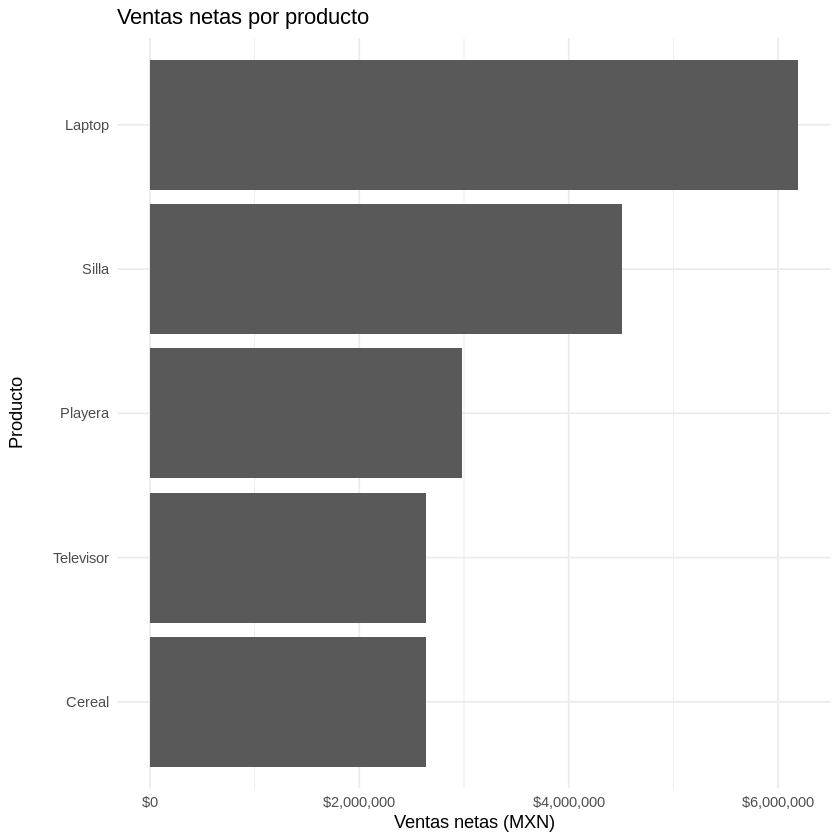

In [17]:
# Grafica 1: Ventas netas por producto
grafica_producto <- ggplot(ventas_producto, aes(x = reorder(producto, ventas_netas), y = ventas_netas)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Ventas netas por producto",
    x = "Producto",
    y = "Ventas netas (MXN)"
  ) +
  theme_minimal()

print(grafica_producto)


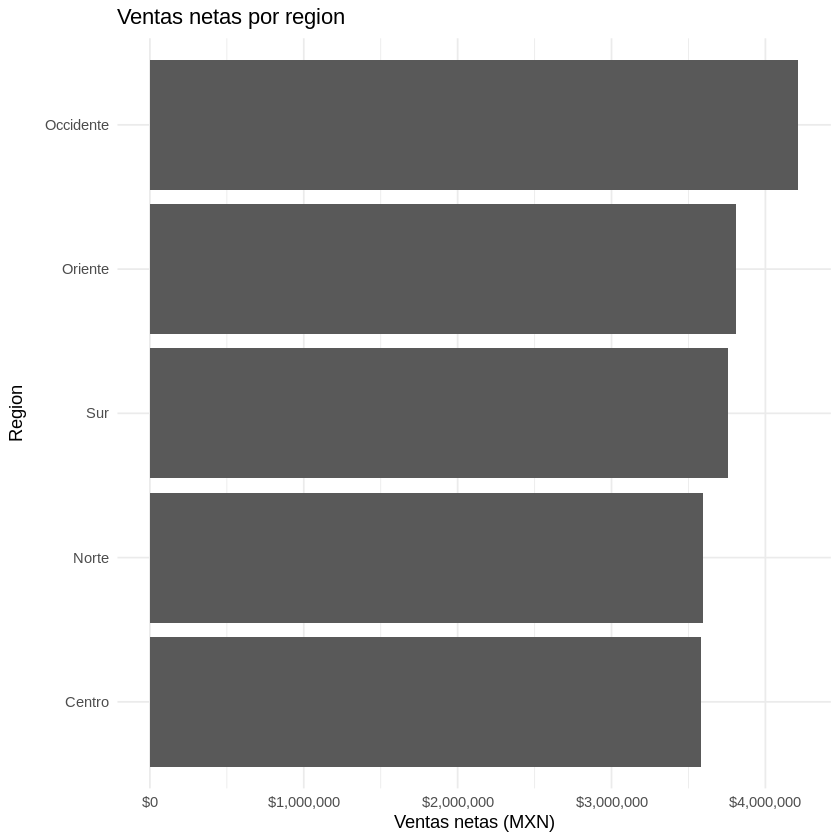

In [18]:
# Grafica 2: Ventas netas por region
grafica_region <- ggplot(ventas_region, aes(x = reorder(region, ventas_netas), y = ventas_netas)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Ventas netas por region",
    x = "Region",
    y = "Ventas netas (MXN)"
  ) +
  theme_minimal()

print(grafica_region)


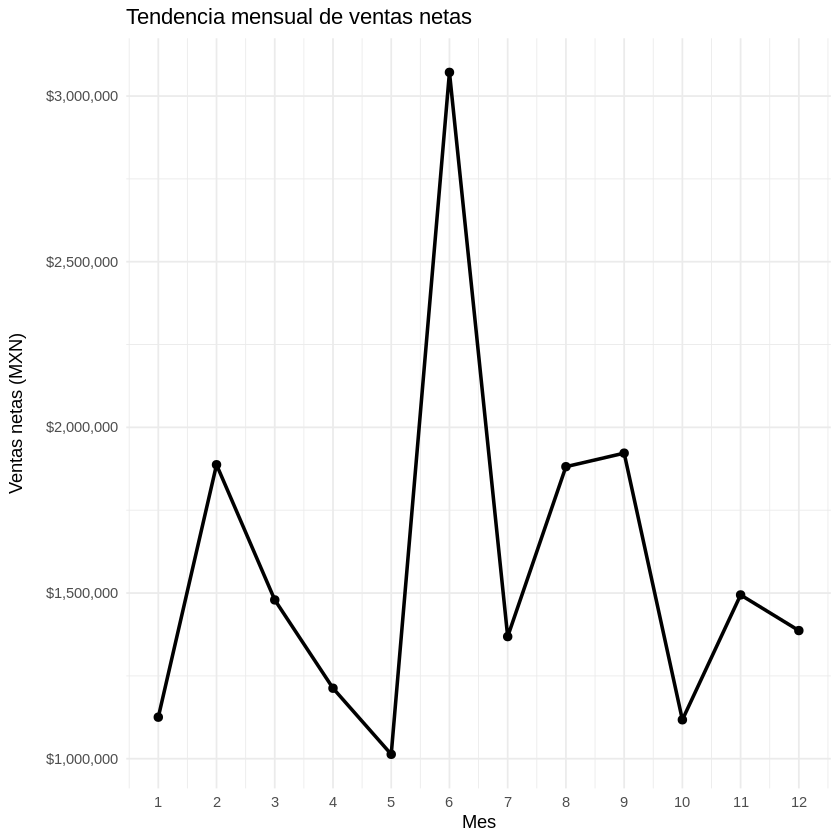

In [19]:
# Grafica 3: Tendencia mensual de ventas
grafica_mes <- ggplot(ventas_mes, aes(x = mes_num, y = ventas_netas)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_x_continuous(breaks = 1:12) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Tendencia mensual de ventas netas",
    x = "Mes",
    y = "Ventas netas (MXN)"
  ) +
  theme_minimal()

print(grafica_mes)

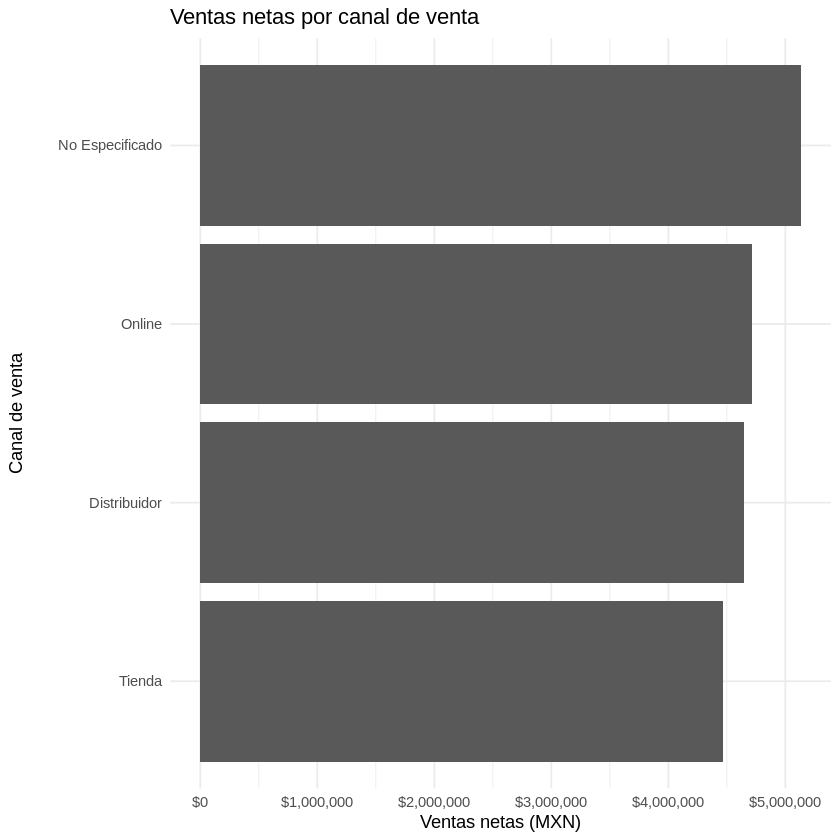

In [20]:
# Grafica 4: Ventas por canal de venta
grafica_canal <- ggplot(ventas_canal, aes(x = reorder(canal_venta, ventas_netas), y = ventas_netas)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Ventas netas por canal de venta",
    x = "Canal de venta",
    y = "Ventas netas (MXN)"
  ) +
  theme_minimal()

print(grafica_canal)


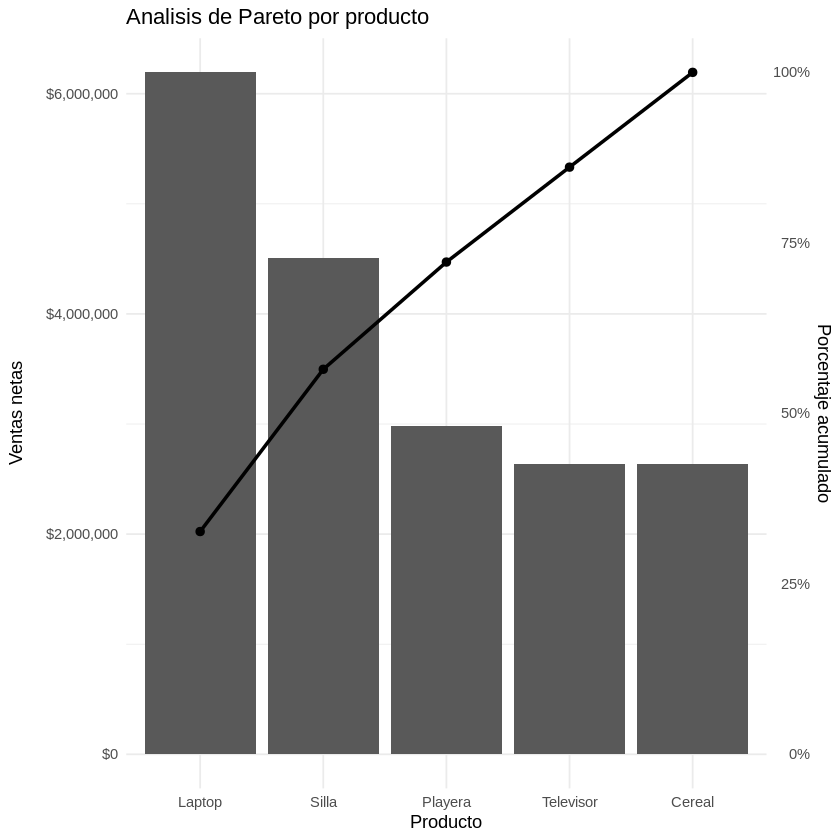

In [21]:

# Grafica 5: Pareto de ventas por producto
grafica_pareto <- ggplot(pareto_producto, aes(x = reorder(producto, -ventas_netas))) +
  geom_col(aes(y = ventas_netas)) +
  geom_line(aes(y = porcentaje_acumulado * max(ventas_netas), group = 1), linewidth = 1) +
  geom_point(aes(y = porcentaje_acumulado * max(ventas_netas)), size = 2) +
  scale_y_continuous(
    name = "Ventas netas",
    labels = dollar_format(prefix = "$", big.mark = ","),
    sec.axis = sec_axis(~ . / max(pareto_producto$ventas_netas),
                        name = "Porcentaje acumulado",
                        labels = percent_format())
  ) +
  labs(
    title = "Analisis de Pareto por producto",
    x = "Producto"
  ) +
  theme_minimal()

print(grafica_pareto)

In [22]:
producto_top <- ventas_producto |> slice_max(ventas_netas, n = 1)
region_top <- ventas_region |> slice_max(ventas_netas, n = 1)
mes_top <- ventas_mes |> slice_max(ventas_netas, n = 1)

cat("\nINSIGHT PRINCIPAL:\n")
cat("El producto con mayores ventas netas fue", producto_top$producto,
    "con", dollar(producto_top$ventas_netas), "\n")
cat("La region con mayores ventas netas fue", region_top$region,
    "con", dollar(region_top$ventas_netas), "\n")
cat("El mes con mayores ventas netas fue el mes", mes_top$mes_num,
    "con", dollar(mes_top$ventas_netas), "\n")

cat("\nDECISION RECOMENDADA:\n")
cat("Se recomienda reforzar inventario y estrategias comerciales en el producto mas vendido, ",
    "analizar las practicas de la region con mejor desempeno y revisar los meses con ventas bajas ",
    "para aplicar promociones o acciones correctivas.\n")


INSIGHT PRINCIPAL:
El producto con mayores ventas netas fue Laptop con $6,193,998 
La region con mayores ventas netas fue Occidente con $4,214,658 
El mes con mayores ventas netas fue el mes 6 con $3,071,392 

DECISION RECOMENDADA:
Se recomienda reforzar inventario y estrategias comerciales en el producto mas vendido,  analizar las practicas de la region con mejor desempeno y revisar los meses con ventas bajas  para aplicar promociones o acciones correctivas.
